In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('sales_data_with_discounts.csv')

In [3]:
df.info()        

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [4]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [5]:
# Missing Values
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [6]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# sselecting Numerical Columns
num_col=['Volume','Avg Price','Total Sales Value','Discount Rate (%)','Discount Amount','Net Sales Value']

In [8]:
des_stats=pd.DataFrame({'mean':df[num_col].mean(),'median':df[num_col].median(),'mode':df[num_col].mode().iloc[0],'std dev':df[num_col].std()})

In [9]:
des_stats

,mean,median,mode,std dev
Volume,5.066667,4.000000,3.000000,4.231602
Avg Price,10453.433333,1450.000000,400.000000,18079.904840
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173
Discount Rate (%),15.155242,16.577766,5.007822,4.220602
Discount Amount,3346.499424,988.933733,69.177942,4509.902963
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624


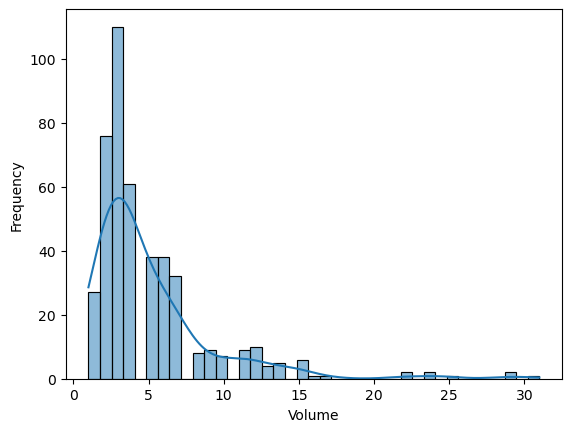

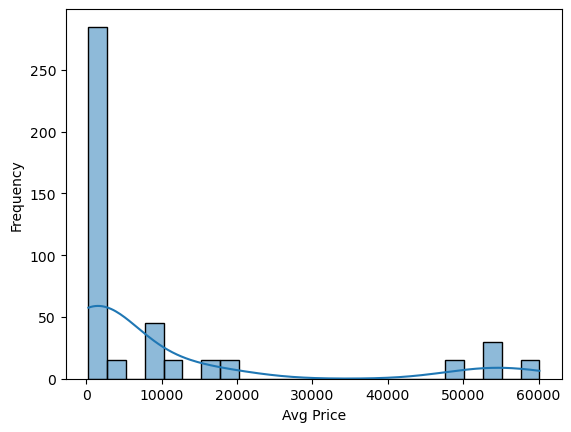

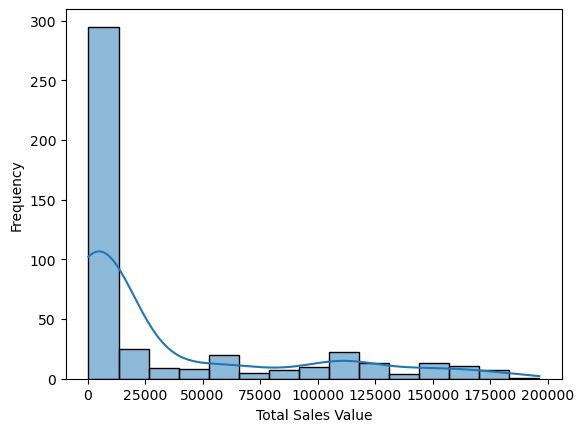

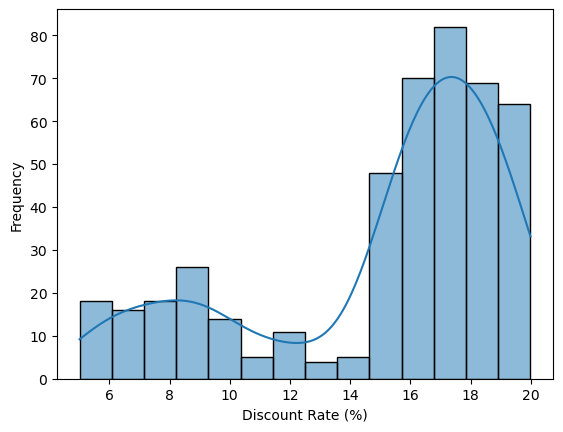

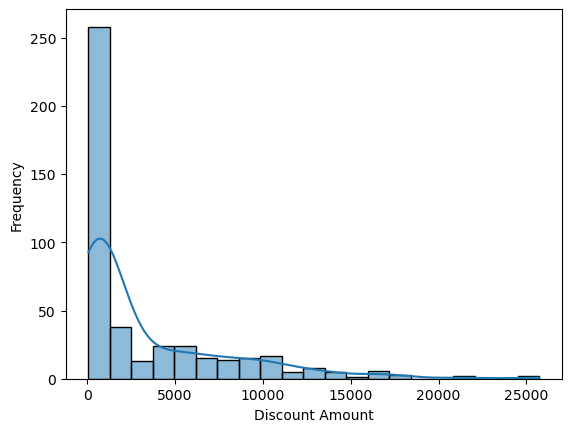

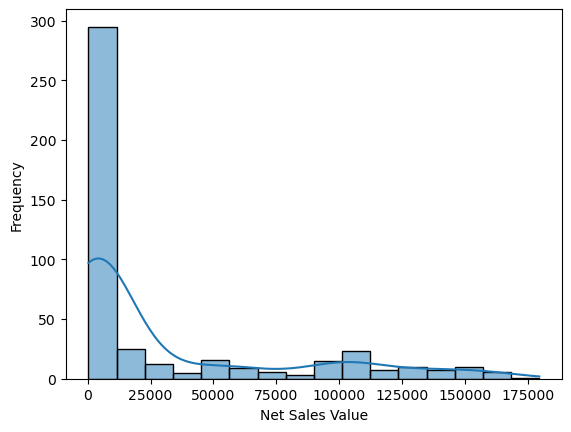

In [28]:
for col in num_col:
    sns.histplot(df[col],kde=True)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

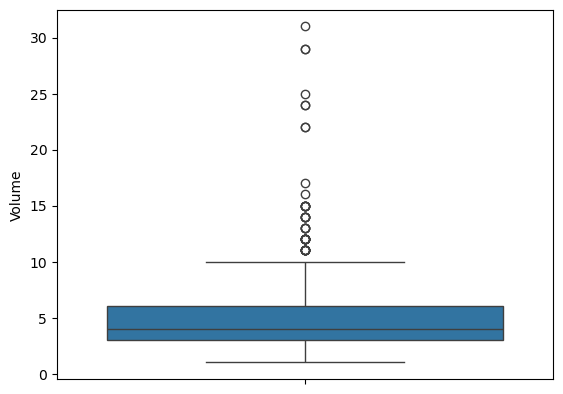

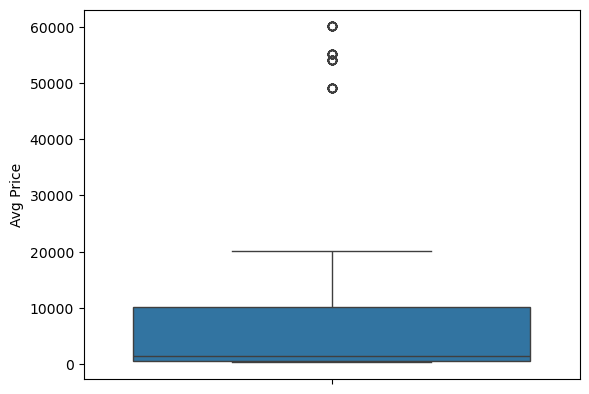

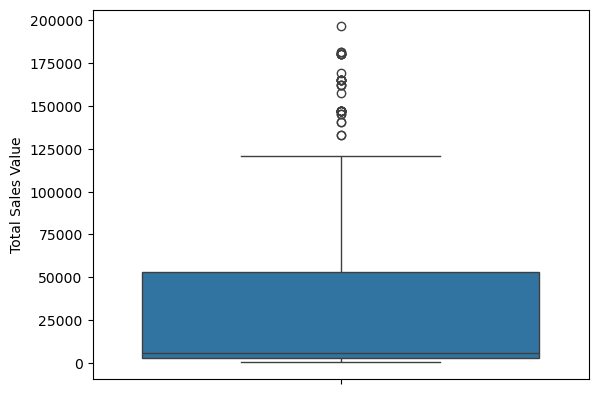

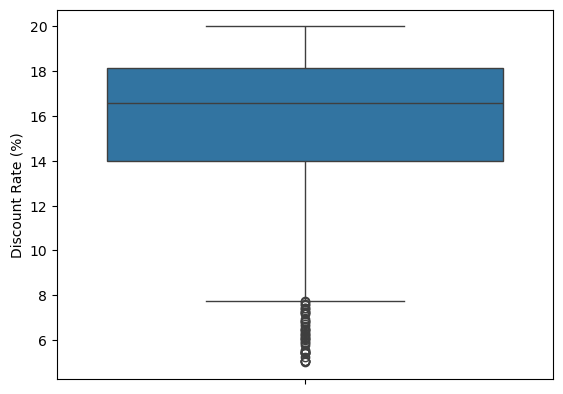

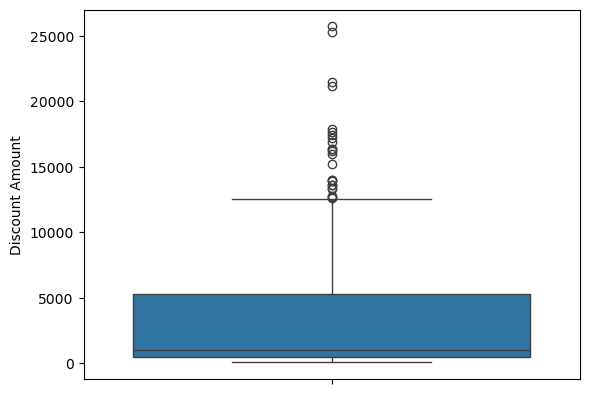

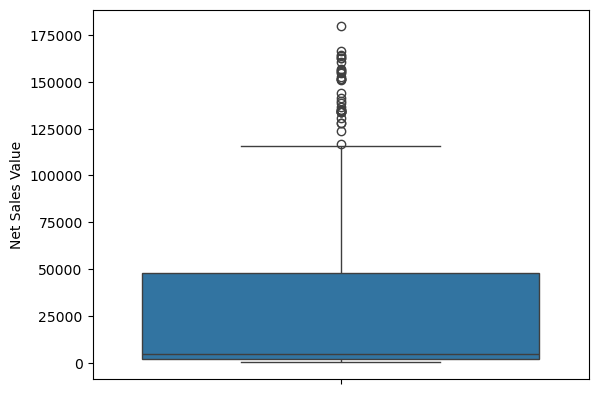

In [30]:
for col in num_col:
    sns.boxplot(df[col])
    plt.show()

In [44]:
### outlier
def outlier_capping(df,column):
    q1= df[column].quantile(0.25)
    q3= df[column].quantile(0.75)
    iqr= q3-q1
    lower_extreme= q1-1.5*iqr
    upper_extreme= q3+1.5*iqr
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

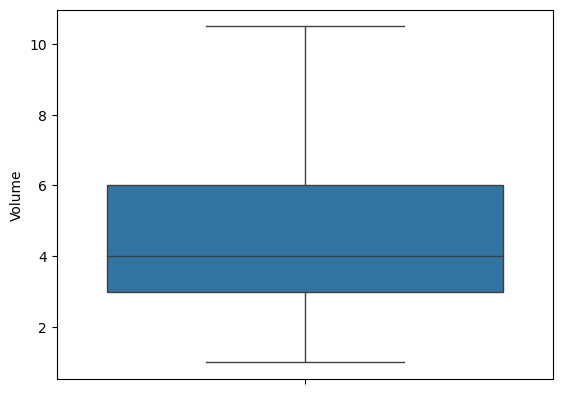

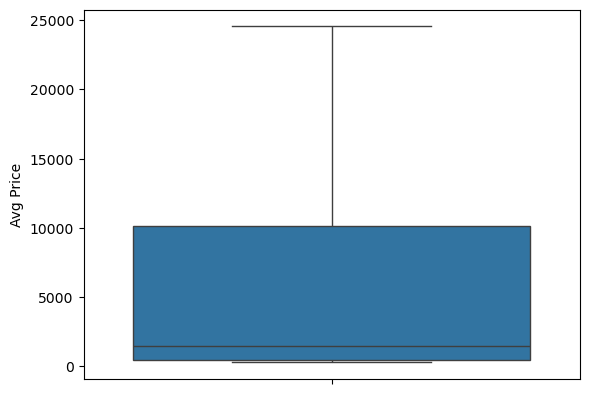

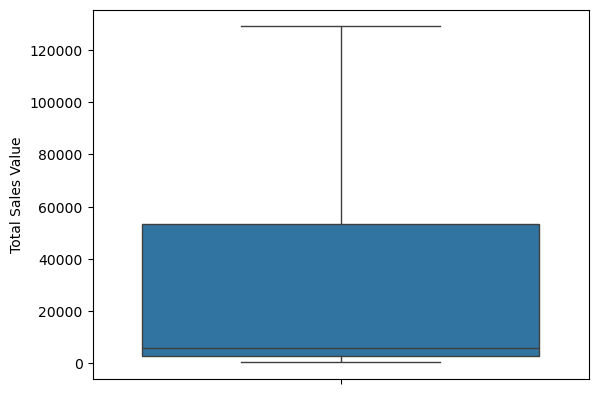

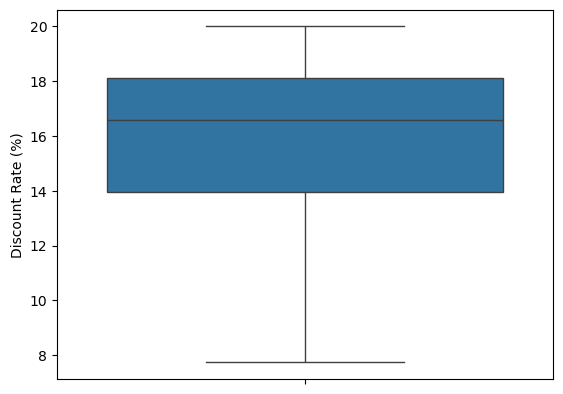

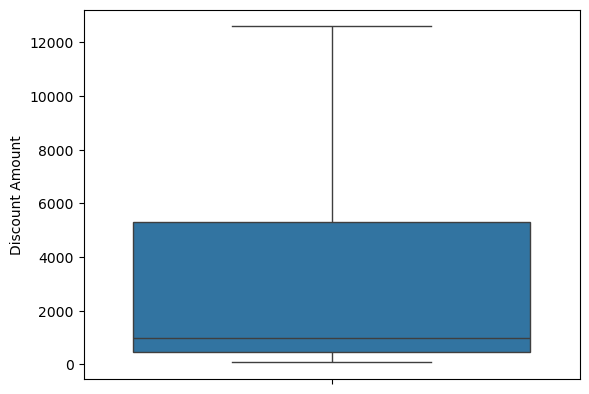

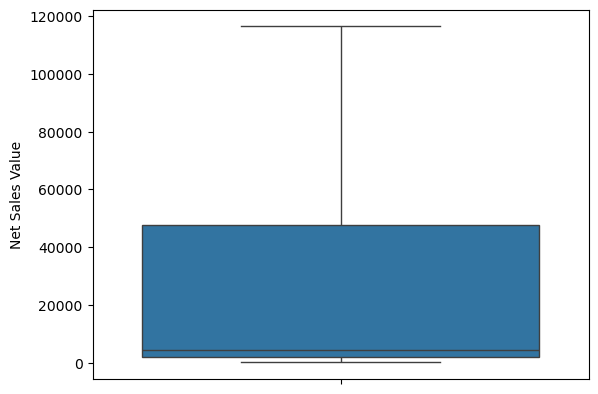

In [45]:
for col in num_col:
    sns.boxplot(df[col])
    plt.show()

In [31]:
cat_col=['Day','City','BU','Brand']

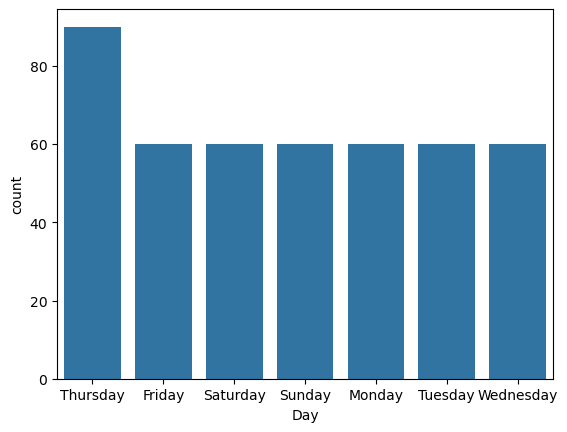

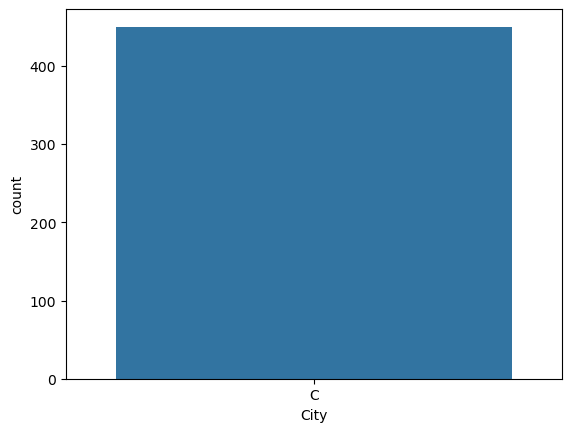

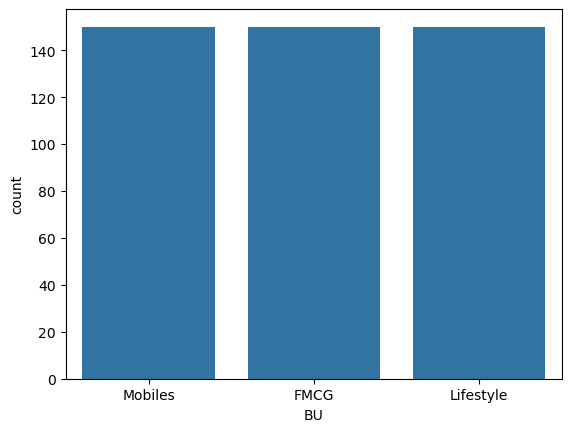

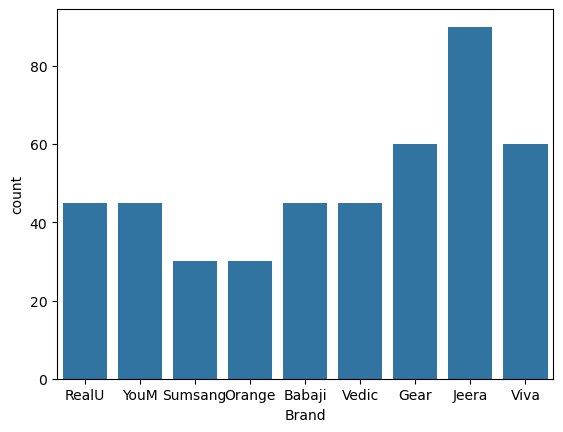

In [43]:
for col in cat_col:
    sns.countplot(x=df[col])
    plt.show()

##### CONCLUSION
sales and discounts are small but a few outliers were found. After removing them, the data looked more clear and the sales numbers are not the same everywhere some cities, brands, and days have higher sales than others.